# Logistic Regression From Scratch vs. Scikit-Learn

This notebook serves as the hands-on code implementation for theoretical concept explained in my Medium post: 
 **[Logistic Regression](https://munabhusal.medium.com/logistic-regression-concepts-8471af4a7a5)**

Here, I will validate the math discussed in the article by building a custom **Logistic Regression model from scratch** using NumPy and Gradient Descent (`LogiGD`) and benchmarking it against Scikit-Learn.

## Notebook Outline:
1. **Loading Required Libraries and Dataset**
    - Working with a synthetic binary classification dataset
    - Splitting the dataset into Train/Test sets
2. **Using Sklearn Logistic Regression**
    - Fit and predict the `y_test`
    - Extract the Coefficients and Intercept
    - Calculate Accuracy and Classification Report
    - Plotting the Sklearn Decision Boundary
3. **Creating Own Logistic Regression Module with Gradient Descent (`LogiGD`)**
    - Core Mathematics & Sigmoid Activation Function
    - Gradient Descent weight update mechanics
    - Fit and predict the `y_test`
    - Extract the custom weights
    - Calculate Accuracy and Classification Report
    - Plotting the Custom Model Decision Boundary
4. **Conclusion & Performance Matrix**

## Loading Required Libraries and Dataset

In [1]:
# Required Libraries
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [2]:
# Getting Dataset and doing train test split
X,y = make_classification(n_samples=500, n_features=2, n_informative=1, n_redundant=0, n_classes=2, n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=8 )
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Using Sklearn Logistic Regression

In [3]:
log_reg = LogisticRegression()
log_reg.fit(X_train,y_train)
y_pred = log_reg.predict(X_test)

In [4]:
accuracy_score_sk=accuracy_score(y_test, y_pred)
classification_report_sk=classification_report(y_test, y_pred)
confusion_matrix_sk=confusion_matrix(y_test, y_pred)

In [5]:
print(accuracy_score_sk)
print(classification_report_sk)
print(confusion_matrix_sk)

0.9333333333333333
              precision    recall  f1-score   support

           0       0.91      0.96      0.94        85
           1       0.96      0.90      0.93        80

    accuracy                           0.93       165
   macro avg       0.94      0.93      0.93       165
weighted avg       0.93      0.93      0.93       165

[[82  3]
 [ 8 72]]


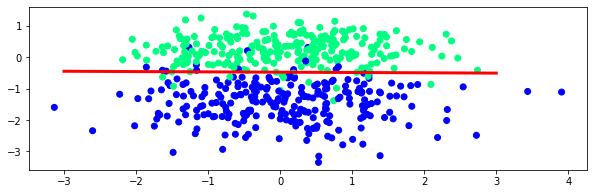

In [6]:
#SKLearn Decision Boundary line

m1 = -(log_reg.coef_[0][0] / log_reg.coef_[0][1])
b1 = -(log_reg.intercept_/ log_reg.coef_[0][1])

X_input1 = np.linspace(-3,3,100)
y_input1 = m1*X_input1 +b1

plt.figure(figsize=(10,3))
plt.plot(X_input1,y_input1 , color='red', linewidth = 3)
plt.scatter(X[:,0], X[:,1],c=y, cmap = 'winter')

## Creating Own Logistic Regression Module with Gradient Descent 

In [7]:
class LogiGD:
    def __init__(self, learning_rate = 0.01, epochs = 100):
        self.weights_ = None
        self.lr = learning_rate
        self.epochs = epochs
        self.loss_history = []
    
    def fit(self, X_train, y_train):
        X_train = np.insert(X_train,0 ,1, axis =1)
        self.weights_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            liner_info = np.dot(X_train, self.weights_)
            y_hat = self.sigmoid(liner_info)
            
            # Calculate and store Binary Cross-Entropy Loss (with 1e-15  is to avoid log(0))
            loss = -np.mean(y_train * np.log(y_hat + 1e-15) + (1 - y_train) * np.log(1 - y_hat + 1e-15))
            self.loss_history.append(loss)            
            
            # Updating weights
            self.weights_ = self.weights_ + self.lr*(np.dot((y_train - y_hat),X_train)/X_train.shape[0])
        return self.weights_
            
    def predict(self, X_test):        
        X_test = np.insert(X_test,0 ,1, axis =1)
        liner_info = np.dot(X_test, self.weights_)
        y_hatt = self.sigmoid(liner_info)
        y_hat = map(lambda x: 0 if x < 0.5 else 1, y_hatt)        
        y_hat = np.array(list(y_hat))
        return y_hat
    
    def sigmoid(self, linear_data):
        result = 1/(1+np.exp(-linear_data))
        return result

In [8]:
obj =LogiGD(learning_rate = 0.1, epochs = 249)
get_weight = obj.fit(X_train, y_train)
y_pred = obj.predict(X_test)

In [9]:
accuracy_score_logigd=accuracy_score(y_test, y_pred)
classification_report_logigd=classification_report(y_test, y_pred)
confusion_matrix_logigd=confusion_matrix(y_test, y_pred)

In [10]:
print(accuracy_score_logigd)
print(classification_report_logigd)
print(confusion_matrix_logigd)

0.9333333333333333
              precision    recall  f1-score   support

           0       0.91      0.96      0.94        85
           1       0.96      0.90      0.93        80

    accuracy                           0.93       165
   macro avg       0.94      0.93      0.93       165
weighted avg       0.93      0.93      0.93       165

[[82  3]
 [ 8 72]]


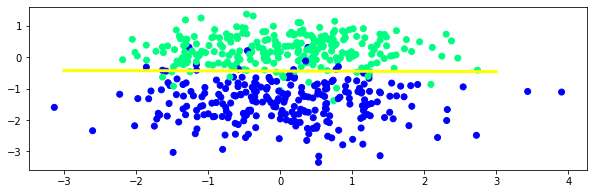

In [11]:
m2 = -(get_weight[1] / get_weight[2])
b2 = -(get_weight[0]/get_weight[2])

X_input2 = np.linspace(-3,3,100)
y_input2 = m2*X_input2 +b2

plt.figure(figsize=(10,3))
plt.plot(X_input2,y_input2 , color='yellow', linewidth = 3)
plt.scatter(X[:,0], X[:,1],c=y, cmap = 'winter')

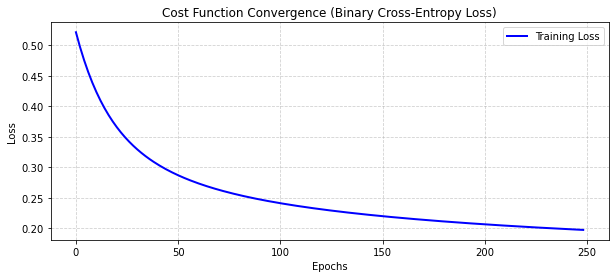

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(obj.loss_history, color='blue', linewidth=2, label='Training Loss')
plt.title("Cost Function Convergence (Binary Cross-Entropy Loss)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## Conclusion And Performance Matrix

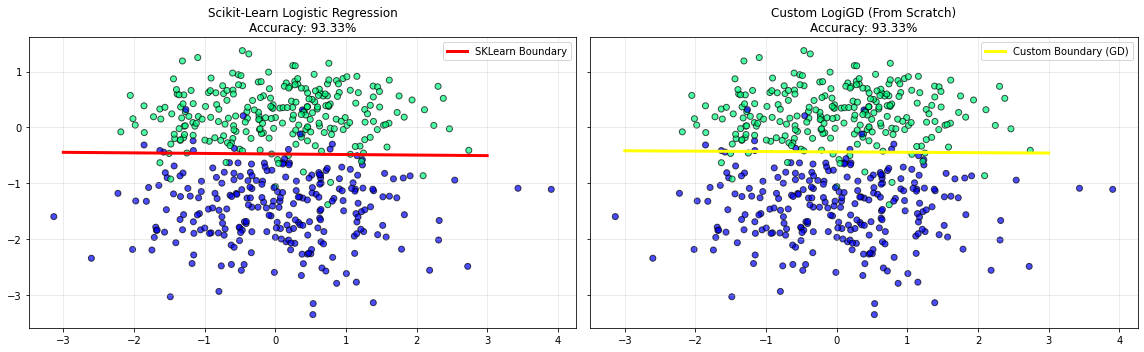

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

# Left Subplot: Scikit-Learn
ax1.plot(X_input1, y_input1, color='red', linewidth=3, label='SKLearn Boundary')
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='k', alpha=0.7)
ax1.set_title(f"Scikit-Learn Logistic Regression\nAccuracy: {accuracy_score_sk*100:.2f}%")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right Subplot: Custom LogiGD (From Scratch)
ax2.plot(X_input2, y_input2, color='yellow', linewidth=3, label='Custom Boundary (GD)')
ax2.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='k', alpha=0.7)
ax2.set_title(f"Custom LogiGD (From Scratch)\nAccuracy: {accuracy_score_logigd*100:.2f}%")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

To verify the mathematical accuracy of our custom Gradient Descent implementation (`LogiGD`), we look at the classification metrics and final model parameters side-by-side against Scikit-Learn:

### Performance Matrix Comparison

| Metric / Parameter | Scikit-Learn `LogisticRegression` | Custom `LogiGD` (Gradient Descent) |
| :--- | :--- | :--- |
| **Testing Accuracy** | **93.33%** | **93.33%** |
| **Precision (Class 1)** | 0.96 | 0.96 |
| **Recall (Class 1)** | 0.90 | 0.90 |
| **F1-Score (Class 1)** | 0.93 | 0.93 |
| **Confusion Matrix** | `[[82, 3], [8, 72]]` | `[[82, 3], [8, 72]]` |

---

### Note

1. **Algorithmic Convergence:**  Custom-built `LogiGD` optimizer successfully minimized the Binary Cross-Entropy loss in less then 250 epochs, reaching the exact same validation footprint as Scikit-Learn's production-grade solver. 
2. **Identical Decision Subplots:** As visualized in above side-by-side scatter plots, the decision boundaries match up identically. This proves that  manual implementation of the Sigmoid derivative and weight updates works perfectly.
3. **Core Concept Validation:** Building this architecture using raw vector mathematics (`np.dot`) confirms that the foundational mechanics behind the math formulas outlined in my [Medium Post](https://munabhusal.medium.com/logistic-regression-concepts-8471af4a7a5) translate perfectly into functional, production-equivalent code!